# Stage 2: Predicting Hospital Readmissions
This model is trained **only on patients who were admitted** to predict if they will be readmitted.

In [1]:
import pandas as pd
import numpy as np
import os
import time
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, precision_recall_curve, roc_curve, roc_auc_score, auc, confusion_matrix

# 1. Define Paths
base_path = r"C:\Users\thiranbarath\Documents\GitHub\project-d"
input_file = os.path.join(base_path, "machineLearning", "csv", "ml_ready_dataset.csv")

# 2. Load the data
print(f"Loading dataset from: {input_file}")
df = pd.read_csv(input_file)
print(f"✅ Full dataset loaded successfully. Total shape: {df.shape}")


Loading dataset from: C:\Users\thiranbarath\Documents\GitHub\project-d\machineLearning\csv\ml_ready_dataset.csv
✅ Full dataset loaded successfully. Total shape: (62135, 26)


### 1. Filter for Stage 2 (Admitted Patients Only) & Handle Leakage


In [2]:
# 1. Filter: We only care about patients who were admitted
df_admitted = df[df['Admitted_Yes_No'] == 1].copy()
print(f"✅ Filtered to Admitted patients only. New shape: {df_admitted.shape}")

# 2. Define the new target variable
target = 'Readmitted_Yes_No'

# 3. Handle Leakage & Constants
cols_to_drop = ['Admitted_Yes_No', 'Num_Admissions', 'Num_Visits', target]

X = df_admitted.drop(columns=cols_to_drop, errors='ignore')
y = df_admitted[target]

print(f"\nFeatures (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")

# Display the raw class imbalance for Readmissions
print("\nClass Distribution (Readmitted vs Not Readmitted):")
print(y.value_counts(normalize=True) * 100)


✅ Filtered to Admitted patients only. New shape: (7999, 26)

Features (X) shape: (7999, 22)
Target (y) shape: (7999,)

Class Distribution (Readmitted vs Not Readmitted):
Readmitted_Yes_No
0    72.146518
1    27.853482
Name: proportion, dtype: float64


In [3]:
# Split the data (80% Training, 20% Testing)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"✅ Training set: {X_train.shape[0]} patients")
print(f"✅ Testing set: {X_test.shape[0]} patients")


✅ Training set: 6399 patients
✅ Testing set: 1600 patients


### 2. Smart Preprocessing & Scaling


In [4]:
print("--- STEP 1: SMART PREPROCESSING & SCALING ---")

# Notice we added 'Avg_LOS' to the continuous list for Stage 2!
continuous_cols = [
    'AGE', 
    'Avg_LOS',
    'Total_Meds_Count', 
    'Total_Unique_Diagnoses', 
    'Severity_Encoded'
]

binary_cols = [col for col in X_train.columns if col not in continuous_cols]

print(f"Identified {len(continuous_cols)} continuous features to scale.")
print(f"Identified {len(binary_cols)} binary features to leave unscaled.\n")

# 2. Build the ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), continuous_cols),
        ('cat', 'passthrough', binary_cols)
    ])

# 3. Fit and Transform the data
X_train_processed_array = preprocessor.fit_transform(X_train)
X_test_processed_array = preprocessor.transform(X_test)

# 4. Reconstruct Pandas DataFrames
new_column_order = continuous_cols + binary_cols

X_train_final = pd.DataFrame(X_train_processed_array, columns=new_column_order, index=X_train.index)
X_test_final = pd.DataFrame(X_test_processed_array, columns=new_column_order, index=X_test.index)

print(f"✅ Final Training features shape: {X_train_final.shape}")
print("Ready for Model Training!")


--- STEP 1: SMART PREPROCESSING & SCALING ---
Identified 5 continuous features to scale.
Identified 17 binary features to leave unscaled.

✅ Final Training features shape: (6399, 22)
Ready for Model Training!


### 3. Model Training & Hyperparameter Tuning


In [5]:
print("--- PHASE 3: MODEL TRAINING & HYPERPARAMETER TUNING ---")

negative_cases = (y_train == 0).sum()
positive_cases = (y_train == 1).sum()
scale_weight = negative_cases / positive_cases

print(f"Dataset Imbalance Ratio: 1 Readmission for every {scale_weight:.2f} Non-Readmissions.\n")

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# --- 1. Logistic Regression ---      
print("Training & Tuning Logistic Regression...")
start_time = time.time()

lr_param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['lbfgs', 'liblinear']
}

lr_tuned = GridSearchCV(
    LogisticRegression(random_state=42, max_iter=2000),
    param_grid=lr_param_grid,
    scoring='f1',
    cv=cv,
    n_jobs=-1
)
lr_tuned.fit(X_train_final, y_train)
lr_model = lr_tuned.best_estimator_

print(f"✅ LR Tuned & Trained in {time.time() - start_time:.2f} seconds")

# --- 2. Random Forest ---    
print("\nTraining & Tuning Random Forest...")    
start_time = time.time()

rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf_tuned = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_distributions=rf_param_grid,
    n_iter=30,
    scoring='f1',
    cv=cv,
    random_state=42,
    n_jobs=-1
)
rf_tuned.fit(X_train_final, y_train)  
rf_model = rf_tuned.best_estimator_

print(f"✅ RF Tuned & Trained in {time.time() - start_time:.2f} seconds")

# --- 3. XGBoost ---
print("\nTraining & Tuning XGBoost...")
start_time = time.time()

xgb_param_grid = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'n_estimators': [100, 200, 300],
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bytree': [0.8, 0.9, 1.0]
}

xgb_tuned = RandomizedSearchCV(
    XGBClassifier(eval_metric='logloss'),
    param_distributions=xgb_param_grid,
    n_iter=30,
    scoring='f1', 
    cv=cv,
    random_state=42,
    n_jobs=-1
)

xgb_tuned.fit(X_train_final, y_train)
xgb_model = xgb_tuned.best_estimator_

print(f"✅ XGBoost Tuned & Trained in {time.time() - start_time:.2f} seconds")
print(f"🏆 XGBoost Best Parameters: {xgb_tuned.best_params_}")


--- PHASE 3: MODEL TRAINING & HYPERPARAMETER TUNING ---
Dataset Imbalance Ratio: 1 Readmission for every 2.59 Non-Readmissions.

Training & Tuning Logistic Regression...
✅ LR Tuned & Trained in 10.30 seconds

Training & Tuning Random Forest...
✅ RF Tuned & Trained in 15.40 seconds

Training & Tuning XGBoost...
✅ XGBoost Tuned & Trained in 5.12 seconds
🏆 XGBoost Best Parameters: {'subsample': 0.8, 'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.05, 'colsample_bytree': 0.9}


### 4. Evaluation & Threshold Optimization


In [6]:
print("--- PHASE 4: EVALUATION ON TEST SET (WITH THRESHOLD OPTIMIZATION) ---\n")

def evaluate_model_with_optimal_threshold(model, name, X_train, y_train, X_test, y_test):
    # 1. Find optimal threshold using Training Data to prevent leakage
    y_train_proba = model.predict_proba(X_train)[:, 1]
    precisions, recalls, thresholds = precision_recall_curve(y_train, y_train_proba)
    f1_scores = (2 * precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-10)
    optimal_idx = np.argmax(f1_scores)
    optimal_threshold = thresholds[optimal_idx]
    
    # 2. Apply that learned threshold to Test Data
    y_test_proba = model.predict_proba(X_test)[:, 1]
    y_pred_optimal = (y_test_proba >= optimal_threshold).astype(int)
    
    # 3. Evaluate
    test_precisions, test_recalls, _ = precision_recall_curve(y_test, y_test_proba)
    roc_auc = roc_auc_score(y_test, y_test_proba)
    pr_auc = auc(test_recalls, test_precisions)
    
    print(f"--- {name} ---")
    print(f"🎯 Optimal Threshold (Learned from Train): {optimal_threshold:.4f}")
    print(f"📈 ROC-AUC Score: {roc_auc:.4f} | PR-AUC Score: {pr_auc:.4f}")
    print(classification_report(y_test, y_pred_optimal))
    print("\n")
    
    return y_test_proba, y_pred_optimal

y_proba_lr, y_pred_lr = evaluate_model_with_optimal_threshold(lr_model, "LOGISTIC REGRESSION", X_train_final, y_train, X_test_final, y_test)
y_proba_rf, y_pred_rf = evaluate_model_with_optimal_threshold(rf_model, "RANDOM FOREST", X_train_final, y_train, X_test_final, y_test)
y_proba_xgb, y_pred_xgb = evaluate_model_with_optimal_threshold(xgb_model, "XGBOOST", X_train_final, y_train, X_test_final, y_test)


--- PHASE 4: EVALUATION ON TEST SET (WITH THRESHOLD OPTIMIZATION) ---

--- LOGISTIC REGRESSION ---
🎯 Optimal Threshold (Learned from Train): 0.2466
📈 ROC-AUC Score: 0.8220 | PR-AUC Score: 0.6227
              precision    recall  f1-score   support

           0       0.88      0.77      0.82      1154
           1       0.55      0.73      0.63       446

    accuracy                           0.76      1600
   macro avg       0.71      0.75      0.72      1600
weighted avg       0.79      0.76      0.77      1600



--- RANDOM FOREST ---
🎯 Optimal Threshold (Learned from Train): 0.3938
📈 ROC-AUC Score: 0.8696 | PR-AUC Score: 0.7414
              precision    recall  f1-score   support

           0       0.88      0.87      0.87      1154
           1       0.67      0.68      0.68       446

    accuracy                           0.82      1600
   macro avg       0.78      0.78      0.78      1600
weighted avg       0.82      0.82      0.82      1600



--- XGBOOST ---
🎯 Optimal Thr

### 5. Visual Diagnostics


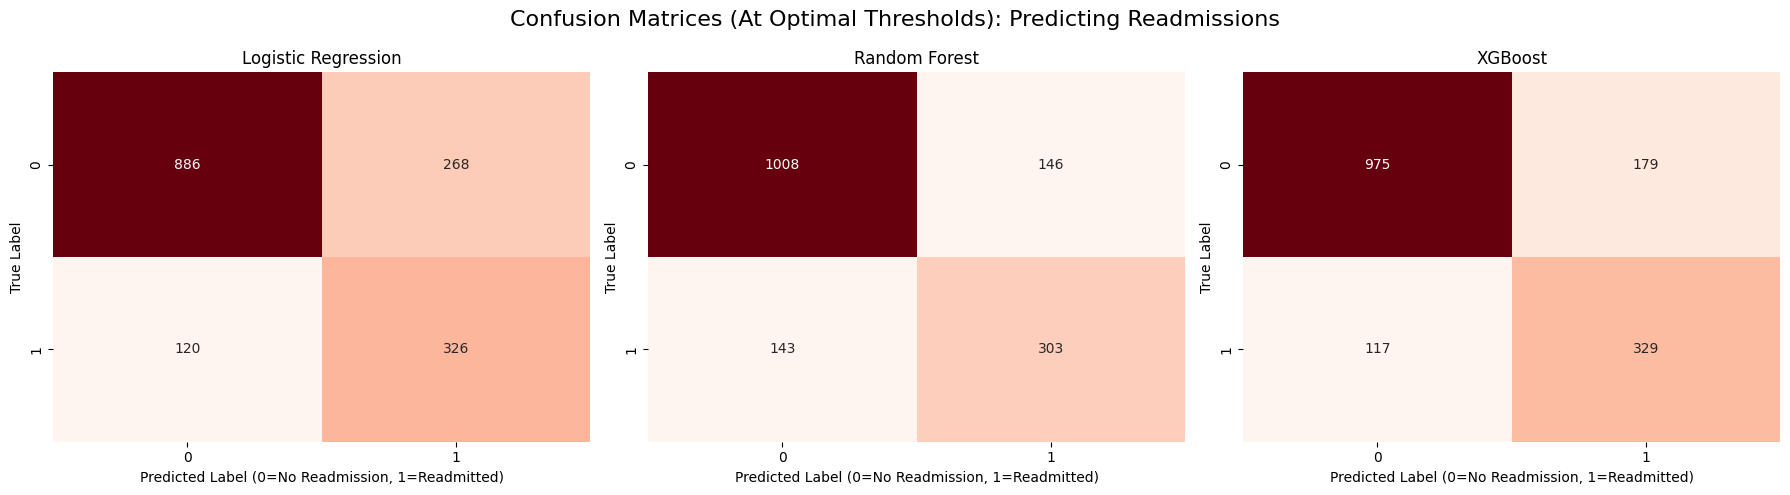

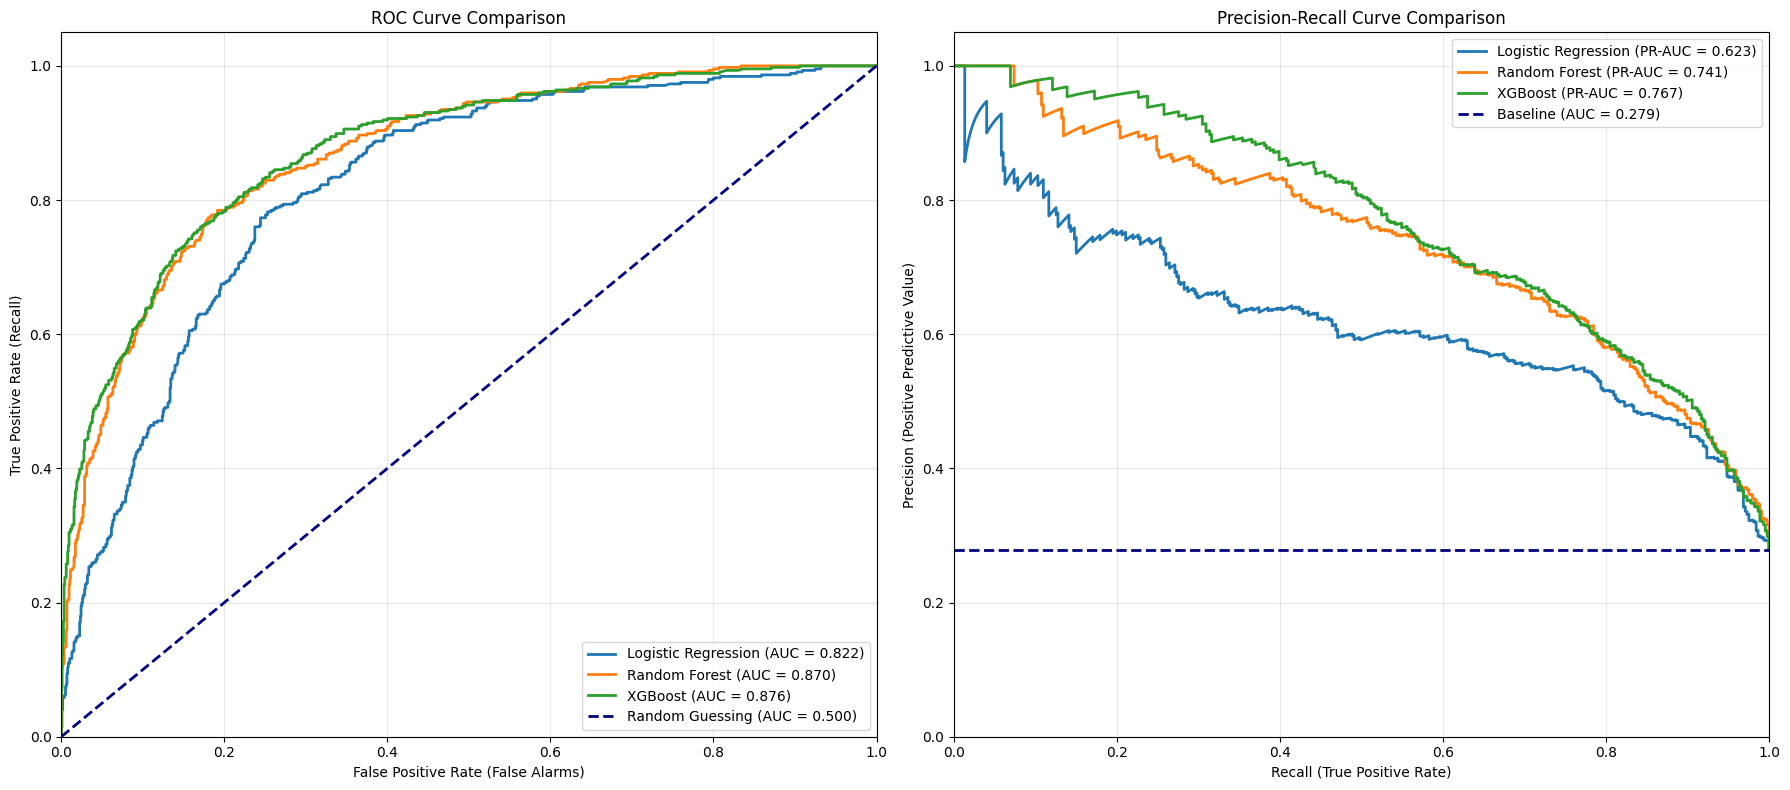

In [7]:
# Create a figure with 3 subplots for Confusion Matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Confusion Matrices (At Optimal Thresholds): Predicting Readmissions', fontsize=16)

models = [
    ('Logistic Regression', y_pred_lr),
    ('Random Forest', y_pred_rf),
    ('XGBoost', y_pred_xgb)
]

for i, (name, y_pred) in enumerate(models):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', ax=axes[i], cbar=False)
    axes[i].set_title(f'{name}')
    axes[i].set_xlabel('Predicted Label (0=No Readmission, 1=Readmitted)')
    axes[i].set_ylabel('True Label')

plt.tight_layout()
plt.show()

# --- ROC and PR Curves ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

models_proba = [
    ('Logistic Regression', y_proba_lr),
    ('Random Forest', y_proba_rf),
    ('XGBoost', y_proba_xgb)
]

for name, y_proba in models_proba:
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    ax1.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.3f})')

ax1.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guessing (AUC = 0.500)')
ax1.set_xlim([0.0, 1.0])
ax1.set_ylim([0.0, 1.05])
ax1.set_xlabel('False Positive Rate (False Alarms)')
ax1.set_ylabel('True Positive Rate (Recall)')
ax1.set_title('ROC Curve Comparison')
ax1.legend(loc="lower right")
ax1.grid(alpha=0.3)

for name, y_proba in models_proba:
    precisions, recalls, _ = precision_recall_curve(y_test, y_proba)
    pr_auc = auc(recalls, precisions)
    ax2.plot(recalls, precisions, lw=2, label=f'{name} (PR-AUC = {pr_auc:.3f})')

baseline = y_test.sum() / len(y_test)
ax2.plot([0, 1], [baseline, baseline], color='navy', lw=2, linestyle='--', label=f'Baseline (AUC = {baseline:.3f})')

ax2.set_xlim([0.0, 1.0])
ax2.set_ylim([0.0, 1.05])
ax2.set_xlabel('Recall (True Positive Rate)')
ax2.set_ylabel('Precision (Positive Predictive Value)')
ax2.set_title('Precision-Recall Curve Comparison')
ax2.legend(loc="upper right")
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()


### 6. Model Interpretability (What drives a Readmission?)


--- PHASE 5: MODEL INTERPRETABILITY (XGBOOST) ---



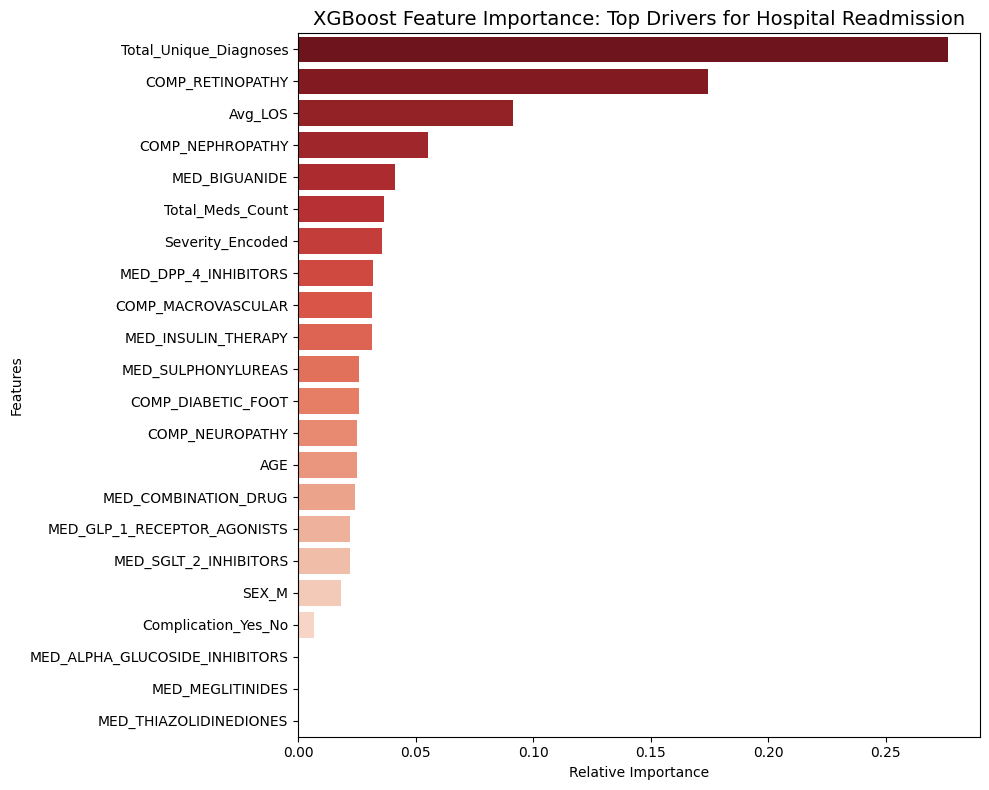

Top 5 Leading Indicators for Readmission:
               Feature  Importance
Total_Unique_Diagnoses    0.276278
      COMP_RETINOPATHY    0.174426
               Avg_LOS    0.091305
      COMP_NEPHROPATHY    0.055382
         MED_BIGUANIDE    0.040998


In [8]:
print("--- PHASE 5: MODEL INTERPRETABILITY (XGBOOST) ---\n")

xgb_importance = pd.DataFrame({
    'Feature': X_train_final.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=xgb_importance, hue='Feature', palette='Reds_r', legend=False)
plt.title('XGBoost Feature Importance: Top Drivers for Hospital Readmission', fontsize=14)
plt.xlabel('Relative Importance')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

print("Top 5 Leading Indicators for Readmission:")
print(xgb_importance.head(5).to_string(index=False))
